# Tâche 1 — Exploration et Prétraitement

Ce notebook couvre uniquement la Tâche 1 :
- Exploration du dataset (distribution par classe)
- Chargement et redimensionnement des images
- Normalisation
- Augmentation de données

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import summarize_split, load_dataset_split
from src.data.preprocess import preprocess_dataset
from src.data.augment import create_training_augmenter, augment_batch

In [2]:
DATA_DIR = PROJECT_ROOT / 'data'
TRAIN_DIR = DATA_DIR / 'Training'
TEST_DIR = DATA_DIR / 'Testing'
IMG_SIZE = (224, 224)

assert TRAIN_DIR.exists(), f'Dossier introuvable: {TRAIN_DIR}'
assert TEST_DIR.exists(), f'Dossier introuvable: {TEST_DIR}'

print('Train dir:', TRAIN_DIR)
print('Test dir :', TEST_DIR)

Train dir: c:\Users\valen\Documents\EFREI\I2\Machine_Learning\Projet\data\Training
Test dir : c:\Users\valen\Documents\EFREI\I2\Machine_Learning\Projet\data\Testing


## 1) Exploration des données

In [3]:
train_summary = summarize_split(TRAIN_DIR)
test_summary = summarize_split(TEST_DIR)

print('[Training]')
for k, v in train_summary.items():
    print(f'- {k:<12}: {v}')

print('\n[Testing]')
for k, v in test_summary.items():
    print(f'- {k:<12}: {v}')

print('\nTotal Training:', sum(train_summary.values()))
print('Total Testing :', sum(test_summary.values()))

[Training]
- glioma      : 1400
- meningioma  : 1400
- pituitary   : 1400
- notumor     : 1400

[Testing]
- glioma      : 400
- meningioma  : 400
- pituitary   : 400
- notumor     : 400

Total Training: 5600
Total Testing : 1600


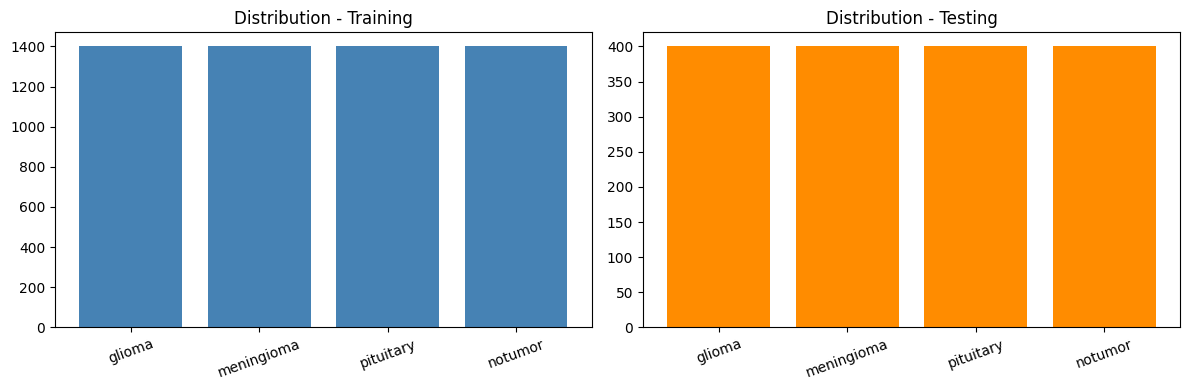

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(train_summary.keys(), train_summary.values(), color='steelblue')
axes[0].set_title('Distribution - Training')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(test_summary.keys(), test_summary.values(), color='darkorange')
axes[1].set_title('Distribution - Testing')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 2) Chargement + Prétraitement (resize, normalisation)

In [5]:
train_split = load_dataset_split(TRAIN_DIR, image_size=IMG_SIZE)
test_split = load_dataset_split(TEST_DIR, image_size=IMG_SIZE, class_names=train_split.class_names)

X_train, y_train = preprocess_dataset(
    train_split.images,
    train_split.labels,
    target_size=IMG_SIZE,
    normalize=True,
    one_hot=False
)

X_test, y_test = preprocess_dataset(
    test_split.images,
    test_split.labels,
    target_size=IMG_SIZE,
    normalize=True,
    one_hot=False
)

print('X_train:', X_train.shape, X_train.dtype, f'min={X_train.min():.3f}, max={X_train.max():.3f}')
print('y_train:', y_train.shape, y_train.dtype)
print('X_test :', X_test.shape, X_test.dtype, f'min={X_test.min():.3f}, max={X_test.max():.3f}')
print('y_test :', y_test.shape, y_test.dtype)
print('Classes:', train_split.class_names)

X_train: (5600, 224, 224, 3) float32 min=0.000, max=1.000
y_train: (5600,) int64
X_test : (1600, 224, 224, 3) float32 min=0.000, max=1.000
y_test : (1600,) int64
Classes: ['glioma', 'meningioma', 'pituitary', 'notumor']


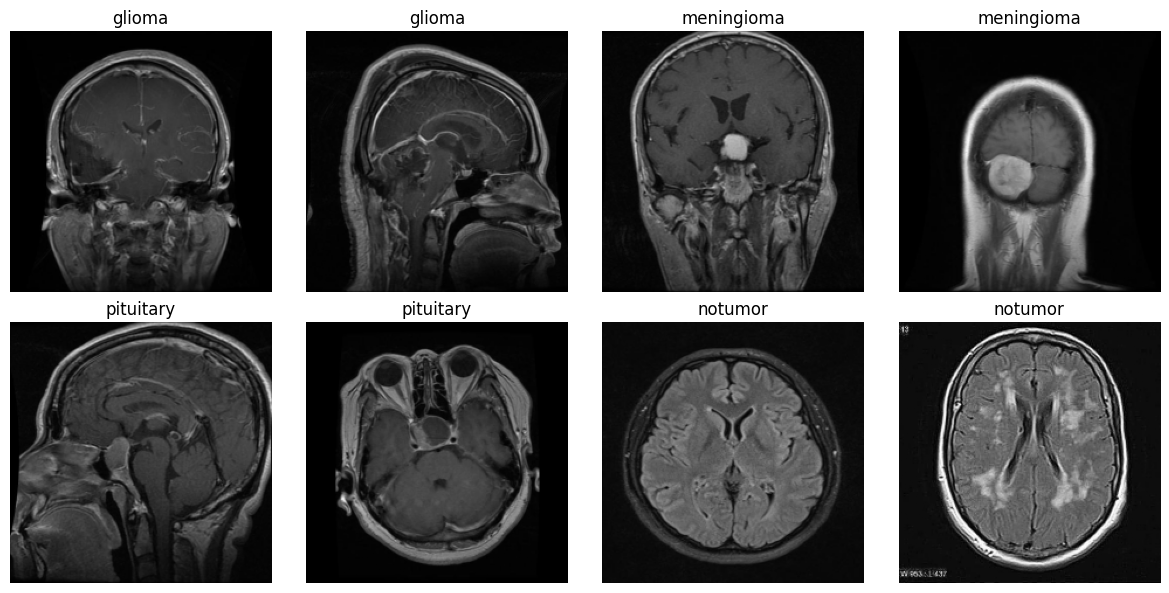

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
indices = np.linspace(0, len(X_train)-1, 8, dtype=int)

for ax, idx in zip(axes.ravel(), indices):
    label_idx = int(y_train[idx])
    label_name = train_split.class_names[label_idx]
    ax.imshow(X_train[idx])
    ax.set_title(label_name)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3) Augmentation de données

In [7]:
augmenter = create_training_augmenter(seed=42)
sample_size = 8
X_sample = X_train[:sample_size]
X_aug = augment_batch(X_sample, augmenter, training=True)

print('Original batch shape :', X_sample.shape)
print('Augmented batch shape:', X_aug.shape)

Original batch shape : (8, 224, 224, 3)
Augmented batch shape: (8, 224, 224, 3)


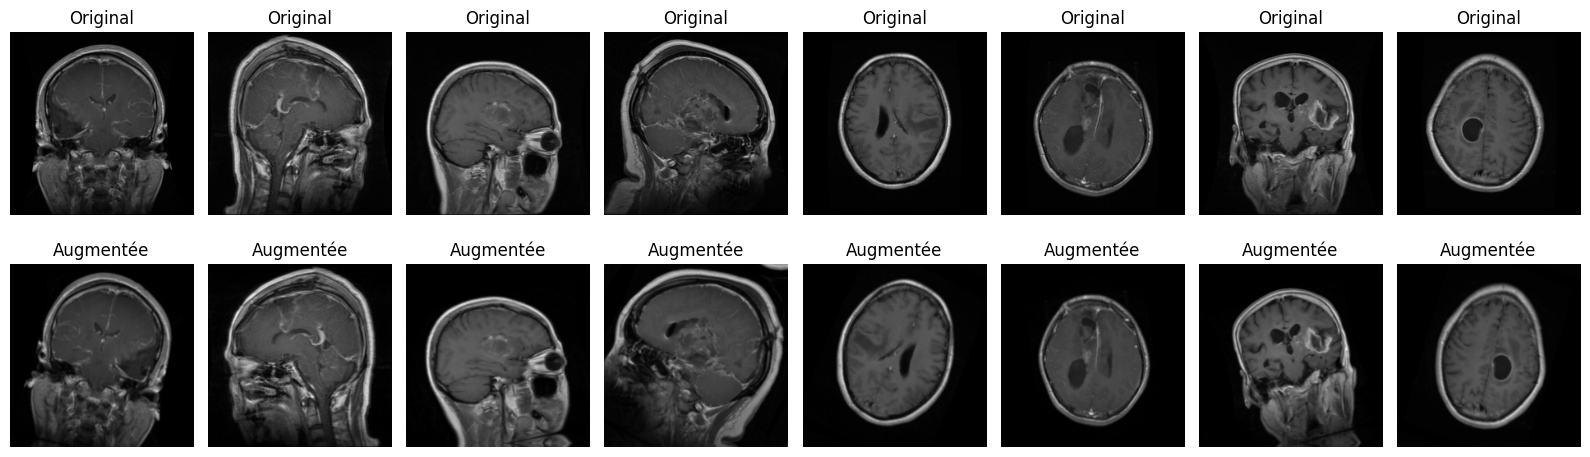

In [8]:
fig, axes = plt.subplots(2, sample_size, figsize=(2 * sample_size, 5))

for i in range(sample_size):
    axes[0, i].imshow(X_sample[i])
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    axes[1, i].imshow(np.clip(X_aug[i], 0.0, 1.0))
    axes[1, i].set_title('Augmentée')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()